# Logistic Regression

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import GridSearchCV



### Data Cleaning

In [2]:
df = pd.read_csv("../Data/coral_regime.csv", low_memory=False)
df = df.replace('nd', pd.NA)

num_cols = ['Latitude_Degrees','Longitude_Degrees','Depth_m','Percent_Cover','Bleaching_Level',
            'Percent_Bleaching','ClimSST','Temperature_Kelvin','Temperature_Mean',
            'Temperature_Minimum','Temperature_Maximum','Temperature_Kelvin_Standard_Deviation',
            'Windspeed','SSTA','SSTA_Mean','SSTA_Maximum','SSTA_Minimum',
            'TSA','TSA_Mean','TSA_Maximum','TSA_Minimum']

df = df[[c for c in num_cols if c in df.columns]]
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=['Percent_Bleaching','Percent_Cover'])

In [3]:
df['Bleaching_Class'] = pd.cut(df['Percent_Bleaching'], bins=[-1,20,50,100], labels=['Low','Medium','High'])
X = df.drop(['Percent_Bleaching','Bleaching_Class'], axis=1)
y = df['Bleaching_Class']

In [4]:
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['Bleaching_Level']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


### Data Splitting

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42, stratify=y)


In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Smote

In [7]:
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

### LR

In [8]:
lr = LogisticRegression(max_iter=500, class_weight='balanced')
lr.fit(X_train_bal, y_train_bal)
y_pred = lr.predict(X_test)

### Stats of model

In [9]:
print("Accuracy:", round(accuracy_score(y_test, y_pred),4))
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.5367
              precision    recall  f1-score   support

        High       0.05      0.77      0.10        71
         Low       0.98      0.53      0.69      4353
      Medium       0.05      0.46      0.08       111

    accuracy                           0.54      4535
   macro avg       0.36      0.59      0.29      4535
weighted avg       0.94      0.54      0.67      4535



### Confusion Metrix of Model

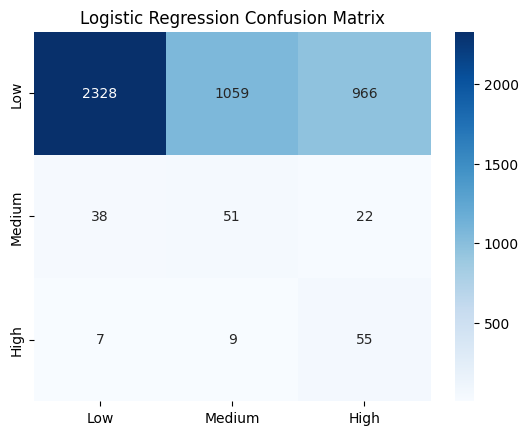

In [10]:
cm = confusion_matrix(y_test, y_pred, labels=['Low','Medium','High'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low','Medium','High'], yticklabels=['Low','Medium','High'])
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Hyperparametric Tuning

## 1.Randomized Search CV

### Build pipeline: PolynomialFeatures + LogisticRegression

In [11]:
 
pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('lr', LogisticRegression(max_iter=500))
])


### Parameter grid

In [12]:

param_grid = {
    'lr__C': [0.1, 1],                 # Regularization strength
    'lr__solver': ['liblinear'],       # Stable solver for small dataset
    'lr__class_weight': ['balanced'],  # Handle class imbalance
    'lr__max_iter': [300]              # Only one iteration count
}

### Randomized Search (5 iterations, 3-fold CV)

In [13]:

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=5,             # Only 5 random combinations
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

### Smote, Parameters, Test Set

In [14]:
# 4️⃣ Fit on SMOTE-balanced training data
random_search.fit(X_train_bal, y_train_bal)

# 5️⃣ Best parameters & model
print("\nBest Parameters Found:")
print(random_search.best_params_)

best_lr = random_search.best_estimator_
# 6️⃣ Predict on test set
y_pred_best = best_lr.predict(X_test)


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 2 is smaller than n_iter=5. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 2 candidates, totalling 6 fits


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(



Best Parameters Found:
{'lr__solver': 'liblinear', 'lr__max_iter': 300, 'lr__class_weight': 'balanced', 'lr__C': 1}


### Stats of RSCV

In [15]:
print("\nTuned Logistic Regression Accuracy:", round(accuracy_score(y_test, y_pred_best), 4))
print(classification_report(y_test, y_pred_best, zero_division=0))


Tuned Logistic Regression Accuracy: 0.6626
              precision    recall  f1-score   support

        High       0.08      0.76      0.15        71
         Low       0.99      0.66      0.79      4353
      Medium       0.06      0.52      0.11       111

    accuracy                           0.66      4535
   macro avg       0.38      0.65      0.35      4535
weighted avg       0.95      0.66      0.77      4535



### Confusion Matrix of RSCV

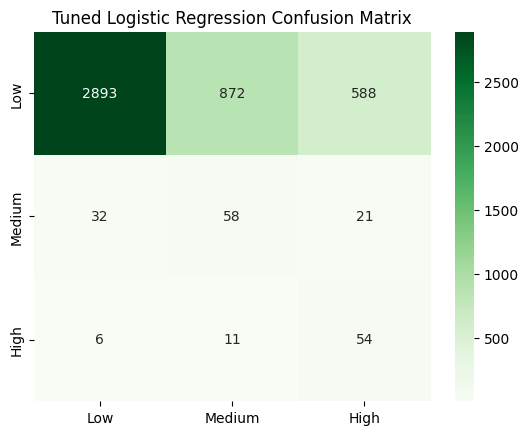

In [16]:
cm = confusion_matrix(y_test, y_pred_best, labels=['Low','Medium','High'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Low','Medium','High'], yticklabels=['Low','Medium','High'])
plt.title("Tuned Logistic Regression Confusion Matrix")
plt.show()


## GridSearch CV

### Define parameter grid

In [17]:


param_grid = {
    'C': [0.01, 0.1, 1, 10],           # Regularization strength
    'solver': ['liblinear', 'lbfgs'],  # Two stable solvers
    'penalty': ['l2'],                 # L2 only (L1 is slower)
    'max_iter': [300, 500, 800],       # Allow more iterations if needed
    'class_weight': ['balanced', None]
}

### Initialize base model

In [18]:
base_lr = LogisticRegression(max_iter=1000)

### GridSearch with 5-fold cross-validation

In [19]:

grid_search = GridSearchCV(
    base_lr,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_bal, y_train_bal)

print("\nBest Parameters Found:")
print(grid_search.best_params_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best Parameters Found:
{'C': 0.01, 'class_weight': 'balanced', 'max_iter': 300, 'penalty': 'l2', 'solver': 'lbfgs'}


### Train with best parameters

In [20]:
best_lr = grid_search.best_estimator_
y_pred_best = best_lr.predict(X_test)

### Evaluation after tuning


Tuned Logistic Regression Accuracy: 0.5424
              precision    recall  f1-score   support

        High       0.05      0.79      0.10        71
         Low       0.98      0.54      0.70      4353
      Medium       0.04      0.39      0.08       111

    accuracy                           0.54      4535
   macro avg       0.36      0.57      0.29      4535
weighted avg       0.94      0.54      0.67      4535



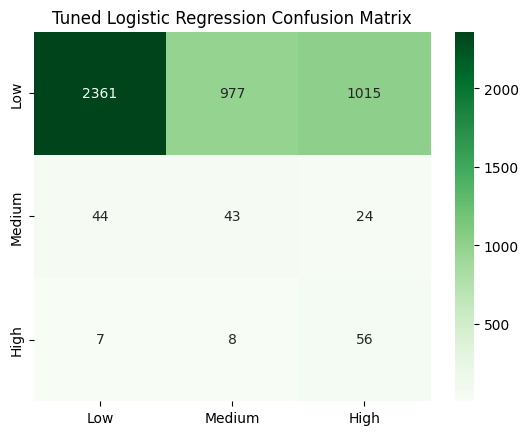

In [21]:
print("\nTuned Logistic Regression Accuracy:", round(accuracy_score(y_test, y_pred_best),4))
print(classification_report(y_test, y_pred_best, zero_division=0))

cm = confusion_matrix(y_test, y_pred_best, labels=['Low','Medium','High'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Low','Medium','High'], yticklabels=['Low','Medium','High'])
plt.title("Tuned Logistic Regression Confusion Matrix")
plt.show()


# Comparision

### Accuracy comparison

C:\Windows\Temp\ipykernel_13260\3034870120.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(accuracy_dict.keys()), y=list(accuracy_dict.values()), palette='viridis')


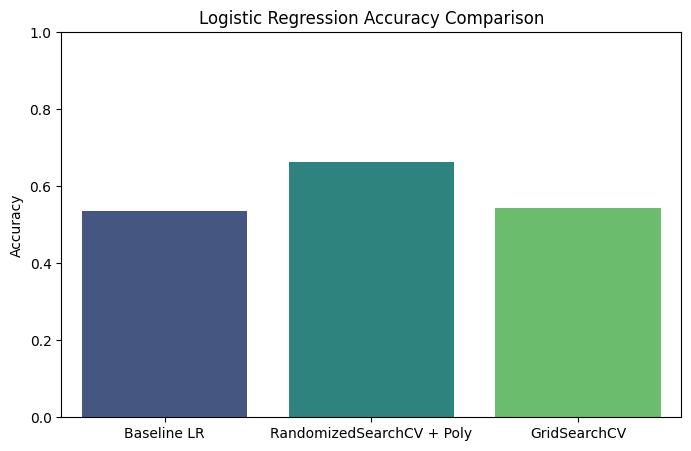

In [22]:

accuracy_dict = {
    'Baseline LR': round(accuracy_score(y_test, lr.predict(X_test)), 4),
    'RandomizedSearchCV + Poly': round(accuracy_score(y_test, random_search.predict(X_test)), 4),
    'GridSearchCV': round(accuracy_score(y_test, grid_search.predict(X_test)), 4)
}

plt.figure(figsize=(8,5))
sns.barplot(x=list(accuracy_dict.keys()), y=list(accuracy_dict.values()), palette='viridis')
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Logistic Regression Accuracy Comparison")
plt.show()

### Confusion Matrices for All Methods

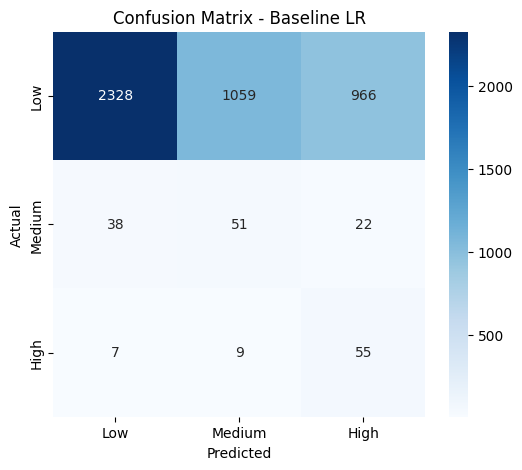

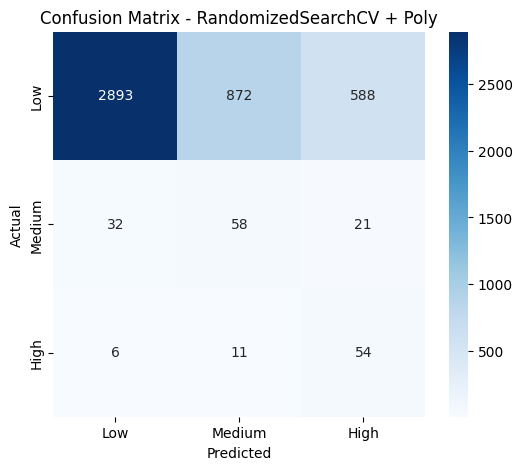

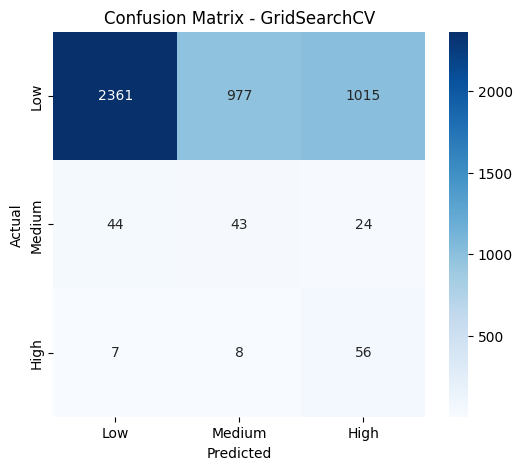

In [23]:
methods = {
    'Baseline LR': lr.predict(X_test),
    'RandomizedSearchCV + Poly': random_search.predict(X_test),
    'GridSearchCV': grid_search.predict(X_test)
}

for name, y_pred in methods.items():
    cm = confusion_matrix(y_test, y_pred, labels=['Low','Medium','High'])
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low','Medium','High'], yticklabels=['Low','Medium','High'])
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


### Class-wise Accuracy Comparison (Optional)

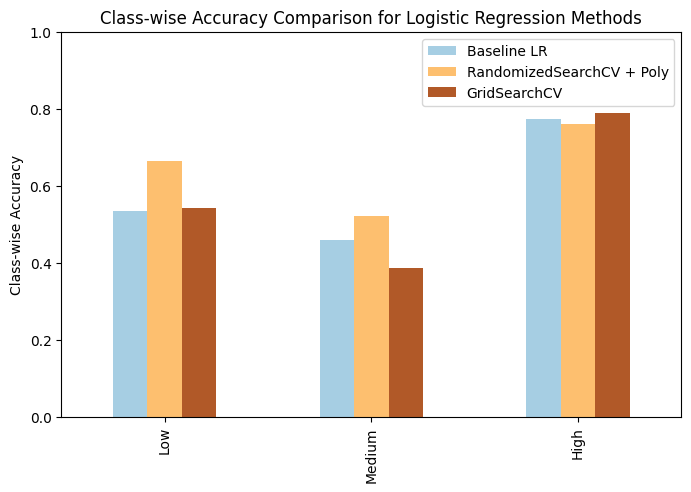

In [24]:
class_acc = {}
for name, y_pred in methods.items():
    cm = confusion_matrix(y_test, y_pred, labels=['Low','Medium','High'])
    class_acc[name] = cm.diagonal() / cm.sum(axis=1)  # Per-class accuracy

class_acc_df = pd.DataFrame(class_acc, index=['Low','Medium','High'])
class_acc_df.plot(kind='bar', figsize=(8,5), colormap='Paired')
plt.ylabel("Class-wise Accuracy")
plt.title("Class-wise Accuracy Comparison for Logistic Regression Methods")
plt.ylim(0,1)
plt.show()

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import joblib

# Save model name and metrics
model_name = "Logistic Regression"
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_mat = confusion_matrix(y_test, y_pred)

# Save metrics for comparison page
results = {
    "Model": model_name,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ConfusionMatrix": conf_mat.tolist()
}

joblib.dump(results, "logistic_results.pkl")


['logistic_results.pkl']

In [26]:
# ✅ Get tuned Logistic Regression model (RandomizedSearchCV)
best_lr = random_search.best_estimator_

# ✅ Predict on test data
y_pred_lr_best = best_lr.predict(X_test)

# ✅ Compute metrics
tuned_lr_results = {
    "Model": "Logistic Regression (Tuned - RSCV)",
    "Accuracy": accuracy_score(y_test, y_pred_lr_best),
    "Precision": precision_score(y_test, y_pred_lr_best, average='weighted'),
    "Recall": recall_score(y_test, y_pred_lr_best, average='weighted'),
    "F1": f1_score(y_test, y_pred_lr_best, average='weighted'),
    "ConfusionMatrix": confusion_matrix(y_test, y_pred_lr_best, labels=['Low','Medium','High']).tolist()
}

joblib.dump(tuned_lr_results, "lr_tuned_results.pkl")
print("✅ Tuned LR accuracy:", tuned_lr_results["Accuracy"])


✅ Tuned LR accuracy: 0.6626240352811467
